# Taller (Colab) — Regresión lineal múltiple: solución desarrollada

**Tema:** coeficientes, significancia y residuales.  
**Archivo final:** listo para ejecutar en Google Colab.

## Requerimientos cubiertos
1. Ajuste del modelo **M3**: `nota ~ horas + asistencia + promedio`.
2. Tabla de coeficientes con error estándar, t, p-valor e IC 95%.
3. Interpretación de `horas`, `asistencia` y `promedio` con signo, magnitud, unidad y la frase “manteniendo constantes”.
4. Interpretación del efecto de **+5 horas**.
5. Prueba de significancia por coeficiente con hipótesis, p-valor, decisión al 5% e IC 95%.
6. Cálculo de residuales y valores ajustados.
7. Dos gráficas: residuales vs ajustados e histograma de residuales.
8. Modelo **M3b** con `horas10 = horas / 10` y comparación de unidades.
9. Párrafo final de síntesis.


## Definiciones mínimas para la sustentación

Para interpretar un coeficiente en regresión múltiple se usa la idea de cambio marginal: si un predictor aumenta en 1 unidad, la nota esperada cambia en el valor estimado del coeficiente, **manteniendo constantes** los demás predictores del modelo.

Para significancia se evalúa `H0: βj = 0` contra `H1: βj ≠ 0`. Si el p-valor es menor que 0.05, se rechaza `H0` al 5%. El IC 95% debe ser coherente con esa decisión: si el intervalo no incluye 0, el coeficiente es significativo al 5%.

Los residuales se calculan como `observado - predicho`. En la gráfica de residuales vs ajustados se espera una nube alrededor de 0; si aparece una curva, puede haber no linealidad, y si aparece forma de abanico, puede fallar la homocedasticidad.


In [ ]:
# 0) LIBRERÍAS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

np.random.seed(2026)
pd.set_option('display.precision', 4)


## Contexto y variables

**Unidad:** estudiante.  
**Y:** `nota` entre 0 y 5.

**Predictores:**
- `horas`: horas de estudio por semana.
- `asistencia`: porcentaje de asistencia entre 0 y 100.
- `promedio`: promedio previo entre 0 y 5.


In [ ]:
# 1) SIMULACIÓN BASE
n = 300

promedio = np.clip(np.random.normal(3.5, 0.5, n), 0, 5)
asistencia = 70 + 8*(promedio-3.5) + np.random.normal(0, 10, n)
asistencia = np.clip(asistencia, 40, 100)
horas = 6 + 2.0*(promedio-3.5) + 0.05*(asistencia-70) + np.random.normal(0, 2.5, n)
horas = np.clip(horas, 0, 25)

eps = np.random.normal(0, 0.35, n)
nota = 0.6 + 0.05*horas + 0.012*asistencia + 0.55*promedio + eps
nota = np.clip(nota, 0, 5)

df = pd.DataFrame({
    'nota': nota,
    'horas': horas,
    'asistencia': asistencia,
    'promedio': promedio
})

df.head()


,nota,horas,asistencia,promedio
0,3.1953,2.2842,52.2924,3.2841
1,3.5160,4.6165,64.9618,2.8036
2,3.9114,2.5652,81.6452,3.6558
3,4.0231,8.3381,63.5462,3.4934
4,4.1592,12.3759,76.2580,4.2249


In [ ]:
# Revisión rápida de las variables simuladas
df.describe().T


,count,mean,std,min,25%,50%,75%,max
nota,300.0,3.7006,0.5662,2.2737,3.2684,3.6829,4.1296,5.0000
horas,300.0,6.5511,2.8620,0.0000,4.5352,6.4934,8.4707,15.8796
asistencia,300.0,70.5849,10.9090,42.3119,64.7232,70.3510,78.2447,100.0000
promedio,300.0,3.5317,0.5064,1.8637,3.2251,3.5630,3.8643,4.8649


# Parte 1 — Ajuste del modelo y coeficientes

Se ajusta el modelo **M3** con `nota` como variable respuesta y `horas`, `asistencia` y `promedio` como predictores.


In [ ]:
# Modelo M3: nota ~ horas + asistencia + promedio
X = sm.add_constant(df[['horas', 'asistencia', 'promedio']])
y = df['nota']

m3 = sm.OLS(y, X).fit()
print(m3.summary())


                            OLS Regression Results                            
Dep. Variable:                   nota   R-squared:                       0.543
Model:                            OLS   Adj. R-squared:                  0.539
Method:                 Least Squares   F-statistic:                     117.4
Date:                Fri, 22 May 2026   Prob (F-statistic):           4.25e-50
Time:                        08:16:11   Log-Likelihood:                -136.99
No. Observations:                 300   AIC:                             282.0
Df Residuals:                     296   BIC:                             296.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6487      0.191      3.404      0.0

In [ ]:
# Tabla resumida de coeficientes
tabla_coef = pd.DataFrame({
    'coeficiente': m3.params,
    'error_estandar': m3.bse,
    't': m3.tvalues,
    'p_valor': m3.pvalues,
    'IC_95_inf': m3.conf_int()[0],
    'IC_95_sup': m3.conf_int()[1]
})

tabla_coef.round(4)


,coeficiente,error_estandar,t,p_valor,IC_95_inf,IC_95_sup
const,0.6487,0.1906,3.4038,0.0008,0.2737,1.0238
horas,0.0412,0.0089,4.6100,0.0000,0.0236,0.0587
asistencia,0.0106,0.0022,4.8173,0.0000,0.0063,0.0150
promedio,0.5753,0.0504,11.4224,0.0000,0.4762,0.6744


## Interpretación de coeficientes

- **Horas:** si `horas` aumenta en **1 hora de estudio por semana**, la **nota esperada** aumenta en aproximadamente **0.0412 puntos**, **manteniendo constantes** la asistencia y el promedio previo.
- **Asistencia:** si `asistencia` aumenta en **1 punto porcentual**, la **nota esperada** aumenta en aproximadamente **0.0106 puntos**, **manteniendo constantes** las horas de estudio y el promedio previo.
- **Promedio:** si `promedio` aumenta en **1 punto de promedio previo**, la **nota esperada** aumenta en aproximadamente **0.5753 puntos**, **manteniendo constantes** las horas de estudio y la asistencia.

Los tres signos son positivos: en este modelo, mayores horas de estudio, mayor asistencia y mayor promedio previo se asocian con una mayor nota esperada.


In [ ]:
# Efecto esperado de aumentar 5 horas de estudio por semana
coef_horas = m3.params['horas']
efecto_5_horas = 5 * coef_horas

print(f"Coeficiente de horas: {coef_horas:.4f}")
print(f"Efecto esperado de +5 horas: {efecto_5_horas:.4f} puntos de nota")


Coeficiente de horas: 0.0412
Efecto esperado de +5 horas: 0.2059 puntos de nota


## Interpretación del efecto de +5 horas

Si las horas de estudio aumentan en **5 horas por semana**, la **nota esperada** aumenta en aproximadamente **0.2059 puntos**, **manteniendo constantes** la asistencia y el promedio previo. Este valor sale de multiplicar el coeficiente de `horas` por 5: `5 × 0.0412 ≈ 0.2059`.


# Parte 2 — Significancia por coeficiente

Para cada predictor se evalúan las mismas hipótesis:

`H0: βj = 0`  
`H1: βj ≠ 0`

La decisión se toma con un nivel de significancia del 5%.


In [ ]:
# Tabla enfocada en significancia de los predictores
predictores = ['horas', 'asistencia', 'promedio']

tabla_significancia = tabla_coef.loc[predictores].copy()
tabla_significancia['rechaza_H0_5%'] = tabla_significancia['p_valor'] < 0.05

tabla_significancia.round(6)


,coeficiente,error_estandar,t,p_valor,IC_95_inf,IC_95_sup,rechaza_H0_5%
horas,0.0412,0.0089,4.6100,6.0000e-06,0.0236,0.0587,True
asistencia,0.0106,0.0022,4.8173,2.0000e-06,0.0063,0.0150,True
promedio,0.5753,0.0504,11.4224,0.0000e+00,0.4762,0.6744,True


## Decisiones e interpretación de significancia

- **Horas:** el p-valor es menor que 0.05 y el IC 95% es aproximadamente `[0.0236, 0.0587]`, por lo tanto **no incluye 0**. Se rechaza `H0`; `horas` es estadísticamente significativo al 5%.
- **Asistencia:** el p-valor es menor que 0.05 y el IC 95% es aproximadamente `[0.0063, 0.0150]`, por lo tanto **no incluye 0**. Se rechaza `H0`; `asistencia` es estadísticamente significativa al 5%.
- **Promedio:** el p-valor es menor que 0.05 y el IC 95% es aproximadamente `[0.4762, 0.6744]`, por lo tanto **no incluye 0**. Se rechaza `H0`; `promedio` es estadísticamente significativo al 5%.

Ser **estadísticamente significativo** no es lo mismo que ser **importante en la práctica**: la importancia también depende de la magnitud del coeficiente, la escala de la variable y el contexto académico.


# Parte 3 — Residuales

Se calculan los valores ajustados del modelo y los residuales. Luego se revisan dos gráficas: residuales vs ajustados e histograma de residuales.


In [ ]:
# Cálculo de valores ajustados y residuales
df_resultados = df.copy()
df_resultados['ajustado'] = m3.fittedvalues
df_resultados['residual'] = m3.resid

df_resultados[['nota', 'ajustado', 'residual']].head()


,nota,ajustado,residual
0,3.1953,3.1880,0.0073
1,3.5160,3.1423,0.3738
2,3.9114,3.7254,0.1859
3,4.0231,3.6773,0.3458
4,4.1592,4.3995,-0.2403


In [ ]:
# Resumen numérico de residuales
df_resultados['residual'].describe()


count    3.0000e+02
mean    -7.1942e-16
std      3.8266e-01
min     -1.1815e+00
25%     -2.4028e-01
50%      9.5244e-03
75%      2.4445e-01
max      1.2082e+00
Name: residual, dtype: float64

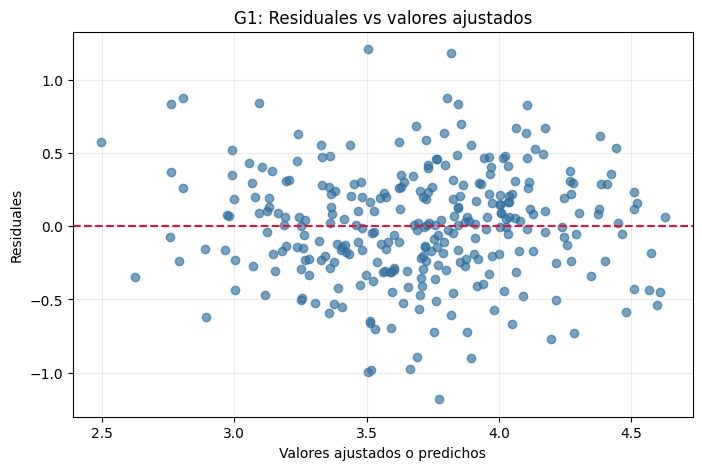

In [ ]:
# G1: Residuales vs valores ajustados
plt.figure(figsize=(8, 5))
plt.scatter(df_resultados['ajustado'], df_resultados['residual'], alpha=0.65, color='#2f6f9f')
plt.axhline(0, color='crimson', linestyle='--', linewidth=1.5)
plt.xlabel('Valores ajustados o predichos')
plt.ylabel('Residuales')
plt.title('G1: Residuales vs valores ajustados')
plt.grid(alpha=0.25)
plt.show()


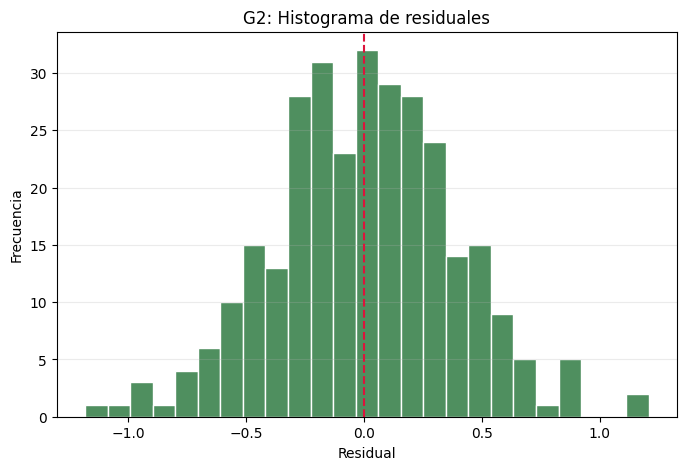

In [ ]:
# G2: Histograma de residuales
plt.figure(figsize=(8, 5))
plt.hist(df_resultados['residual'], bins=25, color='#4f8f5f', edgecolor='white')
plt.axvline(0, color='crimson', linestyle='--', linewidth=1.5)
plt.xlabel('Residual')
plt.ylabel('Frecuencia')
plt.title('G2: Histograma de residuales')
plt.grid(axis='y', alpha=0.25)
plt.show()


## Lectura de residuales

- En la gráfica de residuales vs ajustados se observa principalmente una **nube de puntos alrededor de 0**, sin una curva marcada ni una forma de abanico fuerte.
- Hay algunos residuales relativamente alejados, cercanos a ±1 punto, pero no se ve un patrón extremo que domine el ajuste.
- Si apareciera una forma clara de abanico, el supuesto que podría fallar sería la **homocedasticidad**, es decir, la varianza constante de los errores.


# Parte 4 — Cambio de unidad: `horas10`

Ahora se crea la variable `horas10 = horas / 10`. Una unidad de `horas10` equivale a **10 horas de estudio por semana**.


In [ ]:
# Modelo M3b: nota ~ horas10 + asistencia + promedio
df['horas10'] = df['horas'] / 10

X_m3b = sm.add_constant(df[['horas10', 'asistencia', 'promedio']])
m3b = sm.OLS(df['nota'], X_m3b).fit()

print(m3b.summary())


                            OLS Regression Results                            
Dep. Variable:                   nota   R-squared:                       0.543
Model:                            OLS   Adj. R-squared:                  0.539
Method:                 Least Squares   F-statistic:                     117.4
Date:                Fri, 22 May 2026   Prob (F-statistic):           4.25e-50
Time:                        08:16:12   Log-Likelihood:                -136.99
No. Observations:                 300   AIC:                             282.0
Df Residuals:                     296   BIC:                             296.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6487      0.191      3.404      0.0

In [ ]:
# Comparación entre el coeficiente de horas y el coeficiente de horas10
comparacion_unidades = pd.DataFrame({
    'modelo': ['M3', 'M3b'],
    'variable': ['horas', 'horas10'],
    'unidad_interpretada': ['1 hora', '10 horas'],
    'coeficiente': [m3.params['horas'], m3b.params['horas10']]
})

comparacion_unidades.round(4)


,modelo,variable,unidad_interpretada,coeficiente
0,M3,horas,1 hora,0.0412
1,M3b,horas10,10 horas,0.4117


## Comparación de coeficientes entre M3 y M3b

El coeficiente de `horas` en M3 es aproximadamente **0.0412**, mientras que el coeficiente de `horas10` en M3b es aproximadamente **0.4117**. El número cambia porque la unidad cambió: una unidad de `horas10` representa 10 horas, por eso el coeficiente queda multiplicado por 10.

La interpretación también cambia: en M3, el coeficiente habla del efecto esperado de **1 hora** adicional; en M3b, el coeficiente habla del efecto esperado de **10 horas** adicionales. El modelo no cambia en su ajuste esencial, solo cambia la escala en la que se expresa el predictor.


# Párrafo final

El modelo M3 estima que, manteniendo constantes las demás variables, una hora adicional de estudio por semana se asocia con un aumento aproximado de 0.0412 puntos en la nota esperada.  
También, manteniendo constantes horas y promedio, un punto porcentual adicional de asistencia se asocia con un aumento aproximado de 0.0106 puntos en la nota esperada.  
Por su parte, manteniendo constantes horas y asistencia, un punto adicional en el promedio previo se asocia con un aumento aproximado de 0.5753 puntos en la nota esperada.  
Los tres coeficientes tienen signo positivo, por lo que las tres variables se relacionan directamente con la nota dentro de este modelo.  
En significancia, los p-valores de horas, asistencia y promedio son menores que 0.05, y sus intervalos de confianza al 95% no incluyen cero.  
Por eso se rechaza la hipótesis nula para los tres predictores, aunque esto debe interpretarse como asociación estadística y no como prueba automática de causalidad.  
El análisis de residuales muestra una nube alrededor de cero y no evidencia un patrón fuerte de curva o abanico, lo que respalda razonablemente el ajuste lineal.  
Finalmente, al cambiar de `horas` a `horas10`, el coeficiente pasa de aproximadamente 0.0412 a 0.4117 porque ahora una unidad representa diez horas; cambia la escala de interpretación, no la relación estimada del modelo.
